# Python第6次作业

使用“数据4.3”数据文件（详情已在第4章习题部分中介绍），Profit contribution为利润贡献度，作为响应变量；Net interest income为净利息收入、Intermediate income为中间业务收入、Deposit and finance daily为日均存款加理财之和，均作为特征变量，构建决策树回归算法模型。

In [1]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.tree import DecisionTreeRegressor, export_text
from sklearn.metrics import cohen_kappa_score
from mlxtend.plotting import plot_decision_regions
from sklearn.linear_model import LinearRegression

## 1. 变量设置及数据处理


In [2]:
data = pd.read_csv("../data/数据4.3.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8441 entries, 0 to 8440
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   code                       8441 non-null   int64  
 1   Profit contribution        8441 non-null   float64
 2   Net interest income        8441 non-null   float64
 3   Intermediate income        8441 non-null   float64
 4   Deposit and finance daily  8441 non-null   float64
dtypes: float64(4), int64(1)
memory usage: 329.9 KB


In [3]:
data.isnull().values.any()

False

In [4]:
# 将样本示例全集分割为训练样本和测试样本
X = data.iloc[:, 1:]  # 设置特征变量
y = data.iloc[:, 0]  # 设置响应变量
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=10
)

---

## 2. 未考虑成本-复杂度剪枝的决策树回归算法模型

In [5]:
model = DecisionTreeRegressor(max_depth=2, random_state=10)
model.fit(X_train, y_train)
print("拟合优度：", model.score(X_test, y_test))

拟合优度： 0.0357314987046895


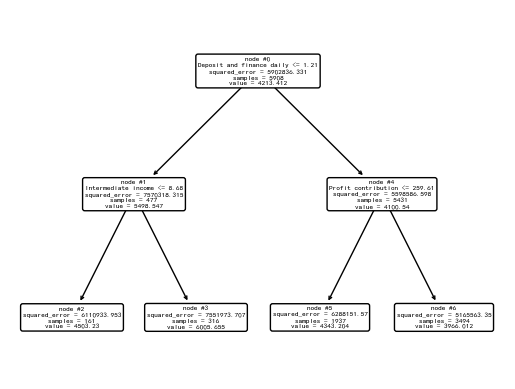

In [6]:
plot_tree(model, feature_names=X.columns, node_ids=True, rounded=True, precision=3)
plt.savefig("out1.pdf")  # 有效解决显示不清晰的问题

In [7]:
print("文本格式的决策树：", export_text(model, feature_names=list(X.columns)))

文本格式的决策树： |--- Deposit and finance daily <= 1.21
|   |--- Intermediate income <= 8.68
|   |   |--- value: [4503.23]
|   |--- Intermediate income >  8.68
|   |   |--- value: [6005.66]
|--- Deposit and finance daily >  1.21
|   |--- Profit contribution <= 259.61
|   |   |--- value: [4343.20]
|   |--- Profit contribution >  259.61
|   |   |--- value: [3966.01]



---

## 3. 构建考虑成本-复杂度剪枝的决策树回归算法模型

In [8]:
model = DecisionTreeRegressor(random_state=10)
path = model.cost_complexity_pruning_path(X_train, y_train)
print("模型复杂度参数：", max(path.ccp_alphas))  # 输出最大的模型复杂度参数
print("模型总均方误差：", max(path.impurities))  # 输出最大的模型总均方误差

模型复杂度参数： 145056.0931541454
模型总均方误差： 5902836.331344441


---

## 4. 绘制图形观察"叶节点总均方误差随alpha值变化情况"

Text(0.5, 1.0, '叶节点总均方误差alpha值变化情况')

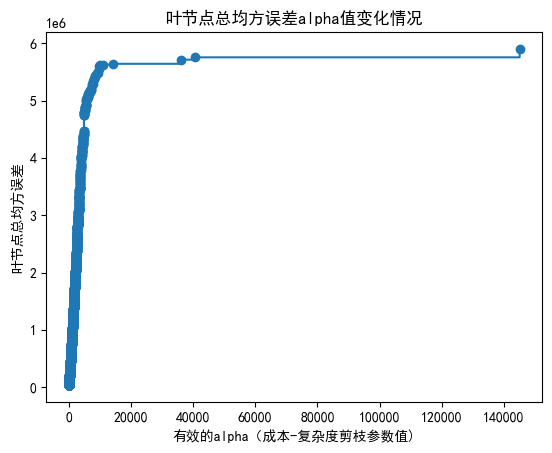

In [9]:
fig, ax = plt.subplots()
ax.plot(path.ccp_alphas, path.impurities, marker="o", drawstyle="steps-post")
ax.set_xlabel("有效的alpha（成本-复杂度剪枝参数值)")
ax.set_ylabel("叶节点总均方误差")
ax.set_title("叶节点总均方误差alpha值变化情况")

---

## 5. 绘制图形观察“节点数和树的深度随alpha值变化情况”

In [10]:
models = []
for ccp_alpha in tqdm(path.ccp_alphas):
    model = DecisionTreeRegressor(random_state=10, ccp_alpha=ccp_alpha)
    model.fit(X_train, y_train)
    models.append(model)
print(
    "最后一棵决策时的节点数为: {} ;其alpha值为: {}".format(
        models[-1].tree_.node_count, path.ccp_alphas[-1]
    )
)  # 输出最path.ccp_alphas中最后一个值，即修剪整棵树的alpha值，只有一个节点

100%|██████████| 4643/4643 [11:00<00:00,  7.03it/s]

最后一棵决策时的节点数为: 1 ;其alpha值为: 145056.0931541454


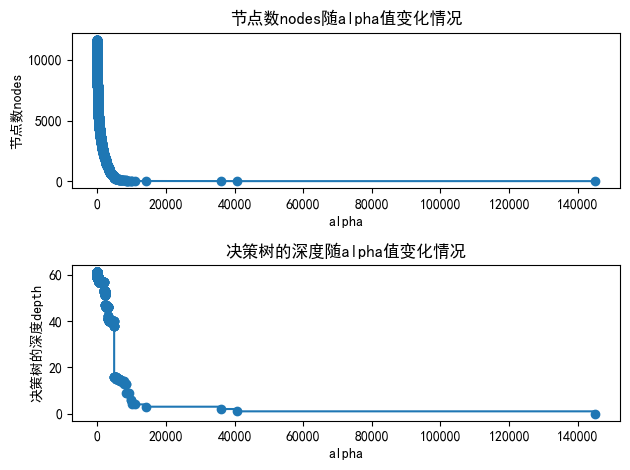

In [11]:
node_counts = [model.tree_.node_count for model in models]
depth = [model.tree_.max_depth for model in models]
fig, ax = plt.subplots(2, 1)
ax[0].plot(path.ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("节点数nodes")
ax[0].set_title("节点数nodes随alpha值变化情况")
ax[1].plot(path.ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("决策树的深度depth")
ax[1].set_title("决策树的深度随alpha值变化情况")
fig.tight_layout()

---

## 6. 绘制图形观察“训练样本和测试样本的拟合优度随alpha值变化情况”

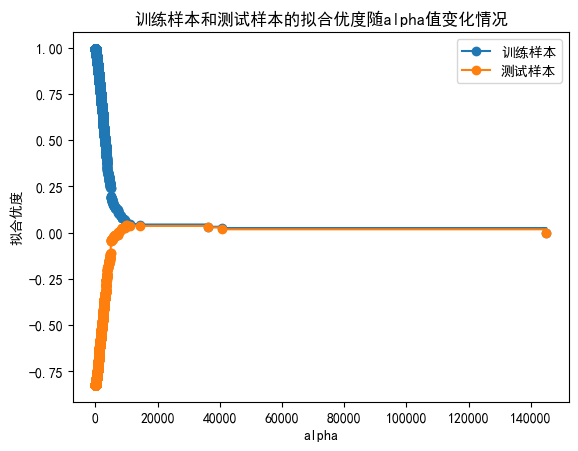

In [12]:
train_scores = [model.score(X_train, y_train) for model in models]
test_scores = [model.score(X_test, y_test) for model in models]
fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("拟合优度")
ax.set_title("训练样本和测试样本的拟合优度随alpha值变化情况")
ax.plot(
    path.ccp_alphas, train_scores, marker="o", label="训练样本", drawstyle="steps-post"
)
ax.plot(
    path.ccp_alphas, test_scores, marker="o", label="测试样本", drawstyle="steps-post"
)
ax.legend()
plt.show()

---

## 7. 通过10折交叉验证法寻求最优alpha值并开展特征变量重要性水平分析

### 7.1 通过10折交叉验证法寻求最优alpha值

In [ ]:
param_grid = {"ccp_alpha": path.ccp_alphas}
kfold = KFold(n_splits=10, shuffle=True, random_state=10)
model = GridSearchCV(DecisionTreeRegressor(random_state=10), param_grid, cv=kfold)
model.fit(X_train, y_train)
print("最优alpha值：", model.best_params_)

In [14]:
model = model.best_estimator_
print("最优拟合优度：", model.score(X_test, y_test))
print("决策树深度：", model.get_depth())
print("叶节点数目：", model.get_n_leaves())
print("每个变量的重要性：", model.feature_importances_)

AttributeError: 'GridSearchCV' object has no attribute 'best_estimator_'

### 7.2 决策树特征变量重要性水平分析

In [15]:
sorted_index = model.feature_importances_.argsort()
plt.barh(range(X_train.shape[1]), model.feature_importances_[sorted_index])
plt.yticks(np.arange(X_train.shape[1]), X_train.columns[sorted_index])
plt.xlabel("特征变量重要性水平")
plt.ylabel("特征变量")
plt.title("决策树特征变量重要性水平分析")
plt.tight_layout()

AttributeError: 'GridSearchCV' object has no attribute 'feature_importances_'

In [ ]:
plot_tree(
    model,
    feature_names=X.columns,
    node_ids=True,
    impurity=True,
    proportion=True,
    rounded=True,
    precision=3,
)
plt.savefig("out2.pdf")

---

## 8. 最优模型拟合效果图形展示

In [ ]:
pred = model.predict(X_test)  # 对响应变量进行预测
t = np.arange(len(y_test))  # 求得响应变量在测试样本中的个数，以便绘制图形。
plt.plot(t, y_test, "r-", linewidth=2, label="原值")  # 绘制响应变量原值曲线。
plt.plot(t, pred, "g-", linewidth=2, label="预测值")  # 绘制响应变量预测曲线。
plt.legend(loc="upper right")  # 将图例放在图的右上方。
plt.grid()
plt.show()

---

## 9. 构建线性回归算法模型进行对比

In [ ]:
model = LinearRegression().fit(X_train, y_train)
model.score(X_test, y_test)